# Change Order Budget Lifecycle Analysis

This notebook analyzes budget change-order item lines by when their parent change orders were created and approved within the project planned lifecycle.

Lifecycle percentages are calculated from the project-level planned envelope:

```text
ProjectPlannedStartDate = earliest contract StartDt across all contracts in the project
ProjectPlannedEndDate = latest contract ClosureDt across all contracts in the project
PercentOfProject = 100 * (ChangeOrderDate - ProjectPlannedStartDate) / ProjectPlannedDurationDays
```

Values are not clipped. A value above 100% means the change order occurred after the original planned project end date. For budget risk, that helps identify whether budget changes appear early enough to be predictive or arrive after the original planned lifecycle has already elapsed.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)

PERCENT_BINS = [-np.inf, 0, 25, 50, 75, 100, 125, 150, 200, 300, 500, 1000, np.inf]
PERCENT_LABELS = ['<0%', '0-25%', '25-50%', '50-75%', '75-100%', '100-125%', '125-150%', '150-200%', '200-300%', '300-500%', '500-1000%', '>1000%']

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df


def add_lifecycle_percentages(df):
    df = df.copy()
    valid_duration = pd.to_numeric(df['PROJECTPLANNEDDURATIONDAYS'], errors='coerce') > 0
    duration = pd.to_numeric(df['PROJECTPLANNEDDURATIONDAYS'], errors='coerce')
    for prefix, date_col in [('Created', 'CHANGEORDERCREATEDON'), ('Approved', 'CHANGEORDERAPPROVEDON')]:
        days_col = f'{prefix}DaysFromProjectStart'
        pct_col = f'{prefix}PercentOfProject'
        bin_col = f'{prefix}LifecycleBin'
        df[days_col] = (df[date_col] - df['PROJECTPLANNEDSTARTDATE']).dt.total_seconds() / 86400.0
        df[pct_col] = np.where(valid_duration & df[date_col].notna(), 100.0 * df[days_col] / duration, np.nan)
        df[bin_col] = pd.cut(df[pct_col], bins=PERCENT_BINS, labels=PERCENT_LABELS, right=True)
    df['HasValidProjectEnvelope'] = valid_duration & df['PROJECTPLANNEDSTARTDATE'].notna() & df['PROJECTPLANNEDENDDATE'].notna()
    return df


def coverage_table(df):
    rows = []
    for c in ['PROJECTPLANNEDSTARTDATE', 'PROJECTPLANNEDENDDATE', 'PROJECTPLANNEDDURATIONDAYS', 'CHANGEORDERCREATEDON', 'CHANGEORDERAPPROVEDON']:
        rows.append({'Field': c, 'NonNullRows': int(df[c].notna().sum()), 'Share': df[c].notna().mean()})
    rows.append({'Field': 'HasValidProjectEnvelope', 'NonNullRows': int(df['HasValidProjectEnvelope'].sum()), 'Share': df['HasValidProjectEnvelope'].mean()})
    return pd.DataFrame(rows)


def pct_summary(df, col):
    s = df[col].dropna()
    if s.empty:
        return pd.DataFrame()
    return s.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).to_frame(col).T


def plot_percent_histograms(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, col, label in [
        (axes[0], 'CreatedPercentOfProject', 'Created'),
        (axes[1], 'ApprovedPercentOfProject', 'Approved'),
    ]:
        s = df[col].dropna()
        ax.hist(s.clip(-100, 500), bins=80, color='#4c78a8', edgecolor='white')
        ax.axvline(100, color='firebrick', linestyle='--', linewidth=1.5, label='Original planned end')
        ax.axvline(0, color='black', linestyle=':', linewidth=1.2, label='Planned start')
        ax.set_title(f'{title}: {label} percent of planned project lifecycle\nvisual clipped to [-100%, 500%]')
        ax.set_xlabel('Percent of planned project lifecycle')
        ax.set_ylabel('Rows')
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_bin_bars(summary, value_col, title, ylabel):
    if summary.empty:
        return
    order = PERCENT_LABELS
    pivot = summary.pivot(index='LifecycleBin', columns='TimingBasis', values=value_col).reindex(order)
    ax = pivot.plot(kind='bar', figsize=(14, 5), color=['#4c78a8', '#f58518'], rot=45)
    ax.set_title(title)
    ax.set_xlabel('Lifecycle bin')
    ax.set_ylabel(ylabel)
    ax.legend(title='Timing basis')
    plt.tight_layout()
    plt.show()

DATA_PATH = Path('all_customer_change_order_budget_lifecycle_2026-06-14-1120.csv')

## Load And Prepare Data

The extract is one row per change-order item line. Created and approved lifecycle percentages are calculated from the parent change order dates. Amount summaries use `AmountDeltaPrimary`, with helper columns retained for validating alternative interpretations.

In [2]:

df = pd.read_csv(DATA_PATH, low_memory=False)
df = parse_dates(df, [
    'PROJECTPLANNEDSTARTDATE', 'PROJECTPLANNEDENDDATE', 'ORIGINALCONTRACTSTARTDATE',
    'ORIGINALCONTRACTENDDATE', 'CHANGEORDERCREATEDON', 'CHANGEORDERAPPROVEDON'
])
df = add_lifecycle_percentages(df)
for c in ['COITEMAMOUNT', 'ORIGINALCONTRACTAMOUNT', 'AMOUNTDELTAPRIMARY', 'AMOUNTDELTAIFFULLREPLACEMENT']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['PositiveDelta'] = df['AMOUNTDELTAPRIMARY'].clip(lower=0)
df['NegativeDelta'] = df['AMOUNTDELTAPRIMARY'].clip(upper=0)
df['AbsDelta'] = df['AMOUNTDELTAPRIMARY'].abs()
print(f'Rows: {len(df):,}')
print(f'Distinct change orders: {df["CHANGEORDERID"].nunique():,}')
print(f'Distinct projects: {df[["CUSTOMERNAME", "PROJECTID"]].drop_duplicates().shape[0]:,}')
display(df.head())


Rows: 49,926
Distinct change orders: 5,524
Distinct projects: 2,728


,CUSTOMERNAME,PROJECTID,PROJECTNAME,PROJECTPLANNEDSTARTDATE,PROJECTPLANNEDENDDATE,PROJECTPLANNEDDURATIONDAYS,PROJECTCONTRACTCOUNT,CONTRACTID,CONTRACTNAME,ORIGINALCONTRACTSTARTDATE,ORIGINALCONTRACTENDDATE,CHANGEORDERID,CHANGEORDERNUMBER,CHANGEORDERCREATEDON,CHANGEORDERAPPROVEDON,ISAPPROVED,CHANGEORDERITEMID,REFERENCEITEMID,REFERENCEITEMTYPE,ORIGINALCONTRACTITEMID,CHANGEORDERITEMLIFECYCLETYPE,COSTANDARDITEMNO,COITEMDESCRIPTION,COITEMQUANTITY,COITEMUNITPRICE,COITEMAMOUNT,ORIGINALSTANDARDITEMNO,ORIGINALITEMDESCRIPTION,ORIGINALCONTRACTQUANTITY,ORIGINALCONTRACTUNITPRICE,ORIGINALCONTRACTAMOUNT,AMOUNTDELTAPRIMARY,AMOUNTDELTAIFFULLREPLACEMENT,CreatedDaysFromProjectStart,CreatedPercentOfProject,CreatedLifecycleBin,ApprovedDaysFromProjectStart,ApprovedPercentOfProject,ApprovedLifecycleBin,HasValidProjectEnvelope,PositiveDelta,NegativeDelta,AbsDelta
0,Adams,38,168th Avenue Over Brantner Ditch,2011-11-28 07:00:00,NaT,NaN,1,34,168th Avenue Over Brantner Ditch,2011-11-28 07:00:00,NaT,76,1,2012-02-22 17:34:35.050,2012-02-24 16:55:42.803,1,27389,NaN,NaN,NaN,New or unreferenced change-order item,203-01597,Potholing,4.0,150.00,600.0,NaN,NaN,NaN,NaN,NaN,600.0,600.0,86.440683,NaN,NaN,88.413690,NaN,NaN,False,600.0,0.0,600.0
1,Adams,38,168th Avenue Over Brantner Ditch,2011-11-28 07:00:00,NaT,NaN,1,34,168th Avenue Over Brantner Ditch,2011-11-28 07:00:00,NaT,76,1,2012-02-22 17:34:35.050,2012-02-24 16:55:42.803,1,27390,25946.0,M,25946.0,Existing referenced contract item,700-70010,F/A Minor Contract Revisions,-600.0,1.00,-600.0,700-70010,F/A Minor Contract Revisions,9400.0,1.0,9400.0,-600.0,-10000.0,86.440683,NaN,NaN,88.413690,NaN,NaN,False,0.0,-600.0,600.0
2,Adams,33,2011 Facilities Project,2011-09-12 06:00:00,NaT,NaN,2,31,2011 Facilities Project,2011-09-12 06:00:00,NaT,49,1,2011-09-12 06:00:00.000,2011-10-07 16:56:24.580,1,25594,NaN,NaN,NaN,New or unreferenced change-order item,408-01000,Hot Poured Joint and Crack Sealant,3.0,3360.00,10080.0,NaN,NaN,NaN,NaN,NaN,10080.0,10080.0,0.000000,NaN,NaN,25.455840,NaN,NaN,False,10080.0,0.0,10080.0
3,Adams,33,2011 Facilities Project,2011-09-12 06:00:00,NaT,NaN,2,31,2011 Facilities Project,2011-09-12 06:00:00,NaT,50,2,2011-09-22 06:00:00.000,2011-10-07 17:29:53.793,1,25597,NaN,NaN,NaN,New or unreferenced change-order item,403-34741,Hot Mix Asphalt (Grading SX) (75) (PG 64-22),21.0,72.00,1512.0,NaN,NaN,NaN,NaN,NaN,1512.0,1512.0,10.000000,NaN,NaN,25.479095,NaN,NaN,False,1512.0,0.0,1512.0
4,Adams,33,2011 Facilities Project,2011-09-12 06:00:00,NaT,NaN,2,31,2011 Facilities Project,2011-09-12 06:00:00,NaT,50,2,2011-09-22 06:00:00.000,2011-10-07 17:29:53.793,1,25598,NaN,NaN,NaN,New or unreferenced change-order item,409-05051,Seal Coat (PMM) (Special),150.0,0.79,118.5,NaN,NaN,NaN,NaN,NaN,118.5,118.5,10.000000,NaN,NaN,25.479095,NaN,NaN,False,118.5,0.0,118.5


## Coverage And Missingness

In [3]:

display(coverage_table(df).style.format({'Share': '{:.1%}'}))
customer_coverage = df.groupby('CUSTOMERNAME').agg(
    Rows=('CHANGEORDERITEMID', 'size'),
    DistinctProjects=('PROJECTID', 'nunique'),
    DistinctChangeOrders=('CHANGEORDERID', 'nunique'),
    HasValidEnvelope=('HasValidProjectEnvelope', 'mean'),
    ApprovedShare=('ISAPPROVED', 'mean'),
    NetAmountDelta=('AMOUNTDELTAPRIMARY', 'sum'),
    PositiveDelta=('PositiveDelta', 'sum'),
    NegativeDelta=('NegativeDelta', 'sum'),
    AbsDelta=('AbsDelta', 'sum'),
).reset_index()
display(customer_coverage.style.format({'HasValidEnvelope': '{:.1%}', 'ApprovedShare': '{:.1%}', 'NetAmountDelta': '${:,.0f}', 'PositiveDelta': '${:,.0f}', 'NegativeDelta': '${:,.0f}', 'AbsDelta': '${:,.0f}'}))


,Field,NonNullRows,Share
0,PROJECTPLANNEDSTARTDATE,49926,100.0%
1,PROJECTPLANNEDENDDATE,39105,78.3%
2,PROJECTPLANNEDDURATIONDAYS,39105,78.3%
3,CHANGEORDERCREATEDON,49926,100.0%
4,CHANGEORDERAPPROVEDON,47936,96.0%
5,HasValidProjectEnvelope,37532,75.2%


,CUSTOMERNAME,Rows,DistinctProjects,DistinctChangeOrders,HasValidEnvelope,ApprovedShare,NetAmountDelta,PositiveDelta,NegativeDelta,AbsDelta
0,Adams,3045,91,353,81.7%,96.4%,"$37,420,087","$76,365,567","$-38,945,480","$115,311,047"
1,Amtrak,5065,7,2493,100.0%,100.0%,"$-36,759,095","$104,271,580","$-141,030,675","$245,302,254"
2,CCD,2765,132,385,100.0%,92.5%,"$28,649,972","$100,260,117","$-71,610,144","$171,870,261"
3,CLV,4458,161,2507,91.0%,85.9%,"$61,209,480","$152,750,582","$-91,541,102","$244,291,684"
4,Lincoln,22900,1266,2389,50.8%,96.8%,"$33,291,155","$92,883,860","$-59,592,705","$152,476,564"
5,UDOT,11693,1071,4655,98.5%,97.4%,"$620,980,636","$2,835,828,899","$-2,214,848,263","$5,050,677,163"


## Budget Delta Sanity Checks

`AmountDeltaPrimary` treats change-order item amounts as event deltas. `AmountDeltaIfFullReplacement` is retained as a diagnostic alternative for referenced existing items.

In [4]:

print('Item lifecycle type distribution')
display(df['CHANGEORDERITEMLIFECYCLETYPE'].value_counts(dropna=False).to_frame('Rows'))
amount_compare = df.groupby('CHANGEORDERITEMLIFECYCLETYPE', dropna=False).agg(
    Rows=('CHANGEORDERITEMID', 'size'),
    NetPrimary=('AMOUNTDELTAPRIMARY', 'sum'),
    NetIfFullReplacement=('AMOUNTDELTAIFFULLREPLACEMENT', 'sum'),
    MedianPrimary=('AMOUNTDELTAPRIMARY', 'median'),
    P01Primary=('AMOUNTDELTAPRIMARY', lambda s: s.quantile(.01)),
    P99Primary=('AMOUNTDELTAPRIMARY', lambda s: s.quantile(.99)),
).reset_index()
display(amount_compare.style.format({'NetPrimary': '${:,.0f}', 'NetIfFullReplacement': '${:,.0f}', 'MedianPrimary': '${:,.0f}', 'P01Primary': '${:,.0f}', 'P99Primary': '${:,.0f}'}))


Item lifecycle type distribution


,Rows
CHANGEORDERITEMLIFECYCLETYPE,
Existing referenced contract item,28719
New or unreferenced change-order item,21166
Referenced item not matched to contract item,41


,CHANGEORDERITEMLIFECYCLETYPE,Rows,NetPrimary,NetIfFullReplacement,MedianPrimary,P01Primary,P99Primary
0,Existing referenced contract item,28719,"$-2,366,892,827","$-11,507,828,786",$-150,"$-293,487","$98,970"
1,New or unreferenced change-order item,21166,"$3,111,254,978","$3,111,254,978","$5,106","$-3,974","$830,453"
2,Referenced item not matched to contract item,41,"$430,085","$430,085","$3,869",$100,"$75,596"


## Raw Lifecycle Percentage Distributions

These are raw percentages, not clipped. Values above 100% indicate activity after the original planned project end date.

Created percent summary


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
CreatedPercentOfProject,37532.0,443.438432,5464.059251,-906.68348,-6.646489,10.241434,22.747403,49.215185,81.031179,138.585946,239.948321,378.019175,866.291008,476251.082433


Approved percent summary


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ApprovedPercentOfProject,35750.0,495.233895,5598.06415,-906.675645,5.858863,20.793215,33.023036,62.670716,96.841528,186.658247,349.087377,511.106458,1093.999137,476252.480581


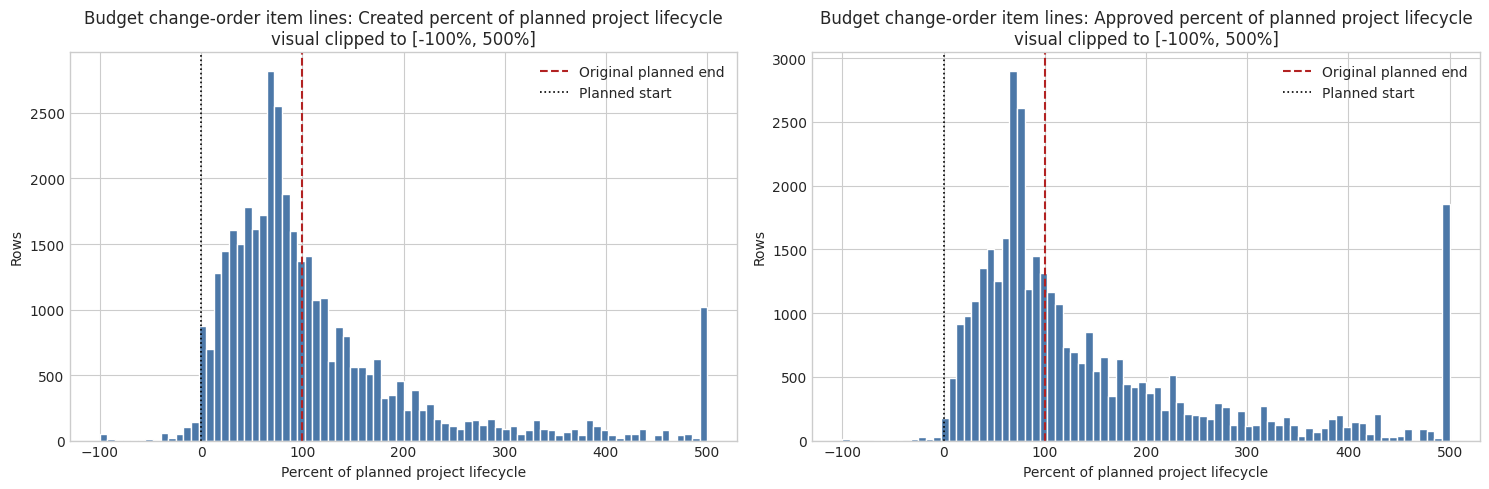

In [5]:

print('Created percent summary')
display(pct_summary(df, 'CreatedPercentOfProject'))
print('Approved percent summary')
display(pct_summary(df, 'ApprovedPercentOfProject'))
plot_percent_histograms(df, 'Budget change-order item lines')


## Binned Counts And Net Cost Sums

,LifecycleBin,ChangeOrderItemRows,DistinctChangeOrders,DistinctProjects,NetAmountDelta,PositiveDelta,NegativeDelta,AbsDelta,MedianLineDelta,TimingBasis
12,<0%,156,35,31,"$14,901,530","$17,512,334","$-2,610,805","$20,123,139","$4,617",ApprovedOn
13,0-25%,2203,769,257,"$49,821,841","$2,201,754,463","$-2,151,932,622","$4,353,687,085","$1,175",ApprovedOn
14,25-50%,4271,1525,389,"$118,635,149","$193,229,885","$-74,594,735","$267,824,620","$2,038",ApprovedOn
15,50-75%,6597,1907,405,"$83,313,982","$225,937,321","$-142,623,340","$368,560,661",$280,ApprovedOn
16,75-100%,5382,1357,461,"$77,317,114","$174,083,783","$-96,766,669","$270,850,452","$1,000",ApprovedOn
17,100-125%,3306,971,387,"$121,713,715","$152,566,679","$-30,852,964","$183,419,643","$2,200",ApprovedOn
18,125-150%,2319,639,319,"$57,570,940","$68,594,022","$-11,023,081","$79,617,103","$2,114",ApprovedOn
19,150-200%,3358,771,418,"$52,031,244","$67,065,550","$-15,034,306","$82,099,856","$1,380",ApprovedOn
20,200-300%,3596,709,410,"$32,479,297","$42,037,572","$-9,558,275","$51,595,847","$1,279",ApprovedOn
21,300-500%,2750,454,285,"$16,025,999","$30,842,596","$-14,816,597","$45,659,193",$509,ApprovedOn


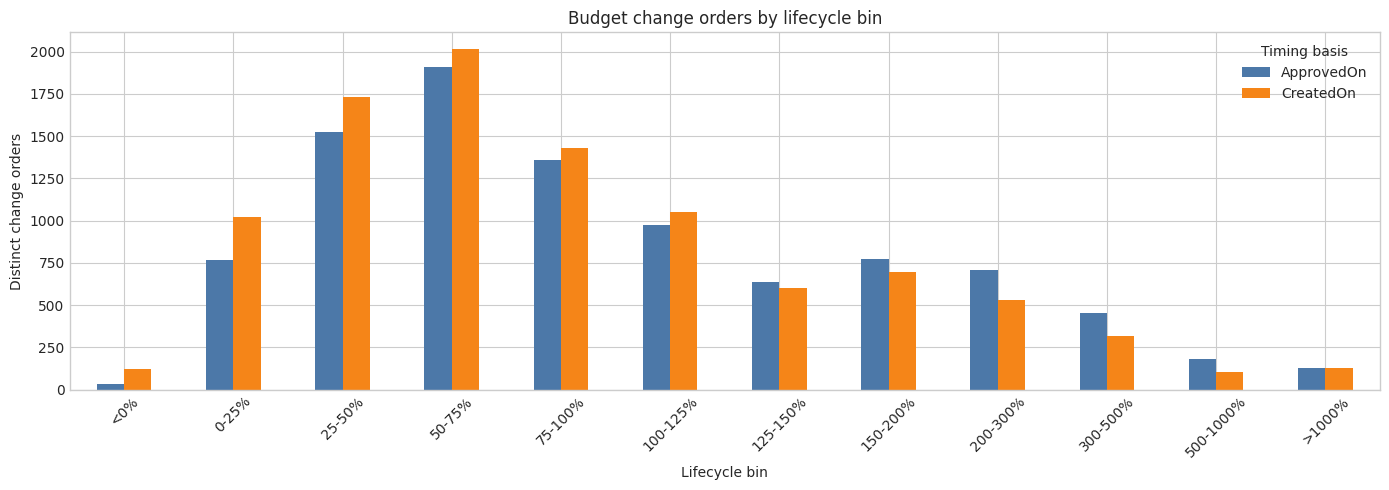

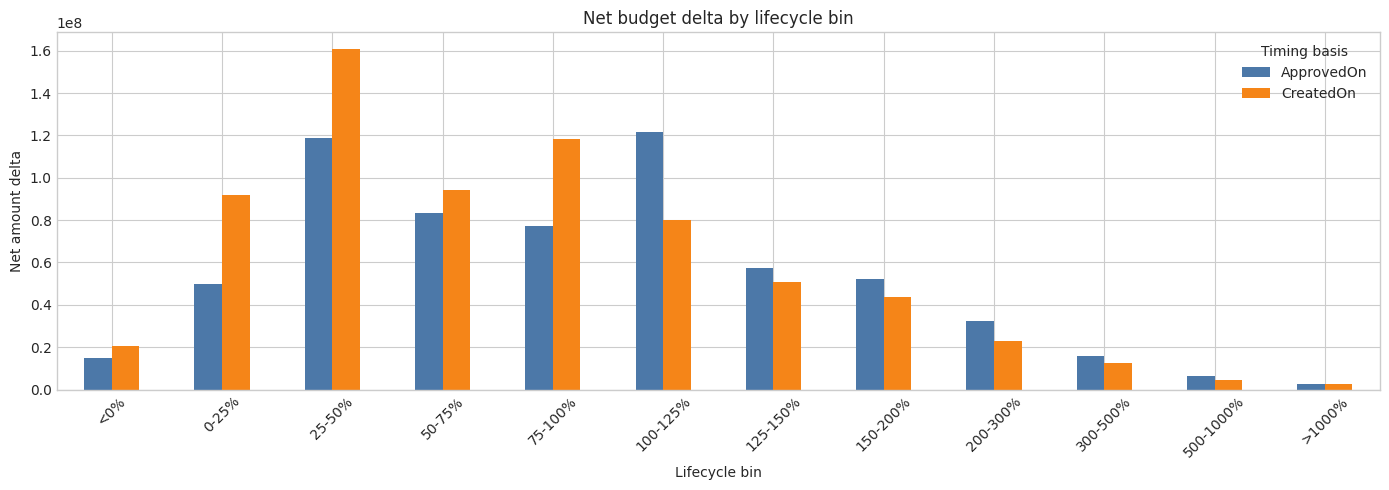

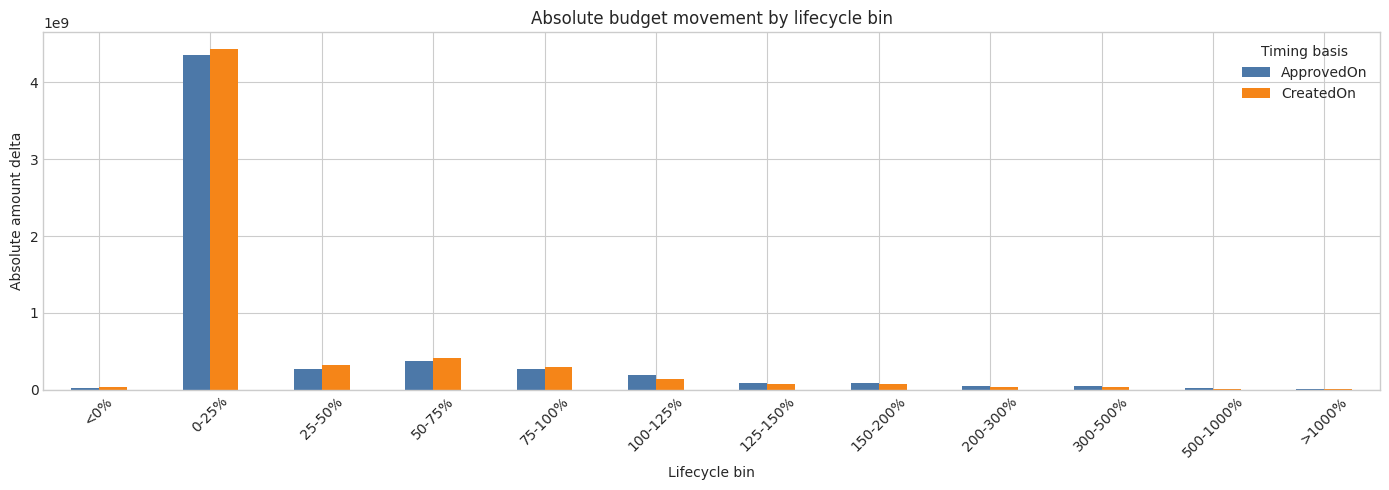

In [6]:

def budget_group(bin_col, label):
    out = df[df[bin_col].notna()].groupby(bin_col, observed=False).agg(
        ChangeOrderItemRows=('CHANGEORDERITEMID', 'size'),
        DistinctChangeOrders=('CHANGEORDERID', 'nunique'),
        DistinctProjects=('PROJECTID', 'nunique'),
        NetAmountDelta=('AMOUNTDELTAPRIMARY', 'sum'),
        PositiveDelta=('PositiveDelta', 'sum'),
        NegativeDelta=('NegativeDelta', 'sum'),
        AbsDelta=('AbsDelta', 'sum'),
        MedianLineDelta=('AMOUNTDELTAPRIMARY', 'median'),
    ).reset_index().rename(columns={bin_col: 'LifecycleBin'})
    out['TimingBasis'] = label
    return out
created = budget_group('CreatedLifecycleBin', 'CreatedOn')
approved = budget_group('ApprovedLifecycleBin', 'ApprovedOn')
bin_summary = pd.concat([created, approved], ignore_index=True)
bin_summary['LifecycleBin'] = pd.Categorical(bin_summary['LifecycleBin'], categories=PERCENT_LABELS, ordered=True)
bin_summary = bin_summary.sort_values(['TimingBasis', 'LifecycleBin'])
display(bin_summary.style.format({'NetAmountDelta': '${:,.0f}', 'PositiveDelta': '${:,.0f}', 'NegativeDelta': '${:,.0f}', 'AbsDelta': '${:,.0f}', 'MedianLineDelta': '${:,.0f}'}))
plot_bin_bars(bin_summary, 'DistinctChangeOrders', 'Budget change orders by lifecycle bin', 'Distinct change orders')
plot_bin_bars(bin_summary, 'NetAmountDelta', 'Net budget delta by lifecycle bin', 'Net amount delta')
plot_bin_bars(bin_summary, 'AbsDelta', 'Absolute budget movement by lifecycle bin', 'Absolute amount delta')


## Late Budget Change-Order Activity

In [7]:

late_summary = pd.DataFrame([
    {
        'TimingBasis': 'CreatedOn',
        'RowsWithPercent': int(df['CreatedPercentOfProject'].notna().sum()),
        'RowsAfter100Pct': int((df['CreatedPercentOfProject'] > 100).sum()),
        'ShareAfter100Pct': (df['CreatedPercentOfProject'] > 100).sum() / max(df['CreatedPercentOfProject'].notna().sum(), 1),
        'NetAmountAfter100Pct': df.loc[df['CreatedPercentOfProject'] > 100, 'AMOUNTDELTAPRIMARY'].sum(),
        'AbsAmountAfter100Pct': df.loc[df['CreatedPercentOfProject'] > 100, 'AbsDelta'].sum(),
    },
    {
        'TimingBasis': 'ApprovedOn',
        'RowsWithPercent': int(df['ApprovedPercentOfProject'].notna().sum()),
        'RowsAfter100Pct': int((df['ApprovedPercentOfProject'] > 100).sum()),
        'ShareAfter100Pct': (df['ApprovedPercentOfProject'] > 100).sum() / max(df['ApprovedPercentOfProject'].notna().sum(), 1),
        'NetAmountAfter100Pct': df.loc[df['ApprovedPercentOfProject'] > 100, 'AMOUNTDELTAPRIMARY'].sum(),
        'AbsAmountAfter100Pct': df.loc[df['ApprovedPercentOfProject'] > 100, 'AbsDelta'].sum(),
    }
])
display(late_summary.style.format({'ShareAfter100Pct': '{:.1%}', 'NetAmountAfter100Pct': '${:,.0f}', 'AbsAmountAfter100Pct': '${:,.0f}'}))
late_by_customer = df.groupby('CUSTOMERNAME').agg(
    Rows=('CHANGEORDERITEMID', 'size'),
    CreatedAfter100=('CreatedPercentOfProject', lambda s: int((s > 100).sum())),
    ApprovedAfter100=('ApprovedPercentOfProject', lambda s: int((s > 100).sum())),
    NetAmount=('AMOUNTDELTAPRIMARY', 'sum'),
    NetAmountCreatedAfter100=('AMOUNTDELTAPRIMARY', lambda s: df.loc[s.index[df.loc[s.index, 'CreatedPercentOfProject'] > 100]].AMOUNTDELTAPRIMARY.sum()),
    NetAmountApprovedAfter100=('AMOUNTDELTAPRIMARY', lambda s: df.loc[s.index[df.loc[s.index, 'ApprovedPercentOfProject'] > 100]].AMOUNTDELTAPRIMARY.sum()),
).reset_index()
display(late_by_customer.style.format({'NetAmount': '${:,.0f}', 'NetAmountCreatedAfter100': '${:,.0f}', 'NetAmountApprovedAfter100': '${:,.0f}'}))


,TimingBasis,RowsWithPercent,RowsAfter100Pct,ShareAfter100Pct,NetAmountAfter100Pct,AbsAmountAfter100Pct
0,CreatedOn,37532,14657,39.1%,"$216,966,447","$372,541,452"
1,ApprovedOn,35750,17141,47.9%,"$288,845,619","$466,633,092"


,CUSTOMERNAME,Rows,CreatedAfter100,ApprovedAfter100,NetAmount,NetAmountCreatedAfter100,NetAmountApprovedAfter100
0,Adams,3045,986,1242,"$37,420,087","$9,260,943","$17,523,294"
1,Amtrak,5065,0,7,"$-36,759,095",$0,"$88,498"
2,CCD,2765,712,696,"$28,649,972","$2,461,507","$2,877,531"
3,CLV,4458,1330,1043,"$61,209,480","$9,926,763","$7,722,022"
4,Lincoln,22900,6501,7555,"$33,291,155","$4,533,222","$7,736,166"
5,UDOT,11693,5128,6598,"$620,980,636","$190,784,012","$252,898,109"


## Exported Notebook Tables

In [8]:

bin_summary.to_csv('change_order_budget_lifecycle_bin_summary_2026-06-14.csv', index=False)
late_summary.to_csv('change_order_budget_lifecycle_late_summary_2026-06-14.csv', index=False)
df.to_csv('change_order_budget_lifecycle_with_percentages_2026-06-14.csv', index=False)
print('Saved budget lifecycle summary CSVs.')


Saved budget lifecycle summary CSVs.
